In [1]:
import sys, numpy, scipy, sklearn, pyod, matplotlib
print("Python:", sys.version.split()[0])
print("numpy:", numpy.__version__)
print("scipy:", scipy.__version__)
print("scikit-learn:", sklearn.__version__)
print("pyod:", pyod.__version__)
print("matplotlib:", matplotlib.__version__)

Python: 3.10.9
numpy: 2.2.6
scipy: 1.15.3
scikit-learn: 1.7.2
pyod: 2.0.5
matplotlib: 3.10.7


In [ ]:
#---------------------------------EX1--------------------------------

from pyod.utils.data import generate_data
import numpy as np

X_train, X_test, y_train, y_test = generate_data(
    n_train=400,
    n_test=100,
    n_features=2,
    contamination=0.1,
    random_state=0
)

y_train = y_train.astype(int)
y_test = y_test.astype(int)

X_train.shape, X_test.shape, np.bincount(y_train), np.bincount(y_test)

((400, 2), (100, 2), array([360,  40]), array([90, 10]))

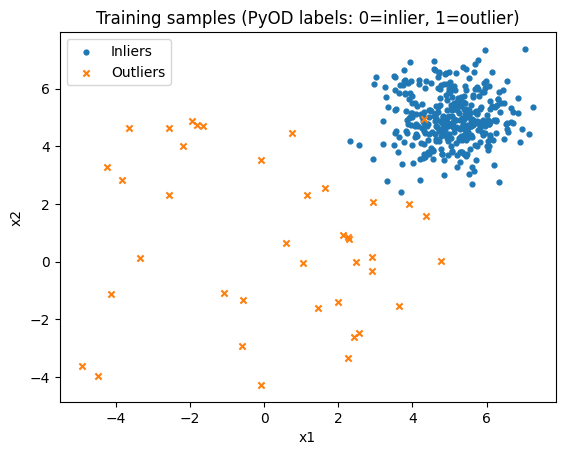

In [5]:
import matplotlib.pyplot as plt

mask_in = (y_train == 0)
mask_out = (y_train == 1)

plt.figure()
plt.scatter(X_train[mask_in, 0], X_train[mask_in, 1], s=12, label="Inliers")
plt.scatter(X_train[mask_out, 0], X_train[mask_out, 1], s=20, marker="x", label="Outliers")
plt.title("Training samples (PyOD labels: 0=inlier, 1=outlier)")
plt.xlabel("x1"); plt.ylabel("x2")
plt.legend()
plt.show()


In [ ]:
#------------------------------------EX2---------------------------------------

from pyod.models.knn import KNN
from sklearn.metrics import confusion_matrix, roc_curve, auc

clf = KNN(contamination=0.1)
clf.fit(X_train)

y_pred_test = clf.predict(X_test)
scores_test = clf.decision_function(X_test) 

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test).ravel()
tpr = tp / (tp + fn) if (tp + fn) else 0.0
tnr = tn / (tn + fp) if (tn + fp) else 0.0
balanced_acc = 0.5 * (tpr + tnr)

fpr, tpr_pts, _ = roc_curve(y_test, scores_test)
auc_value = auc(fpr, tpr_pts)

print(f"TN={tn} FP={fp} FN={fn} TP={tp}")
print(f"Balanced Accuracy = {balanced_acc:.3f}")
print(f"AUC = {auc_value:.3f}")

TN=90 FP=0 FN=0 TP=10
Balanced Accuracy = 1.000
AUC = 1.000


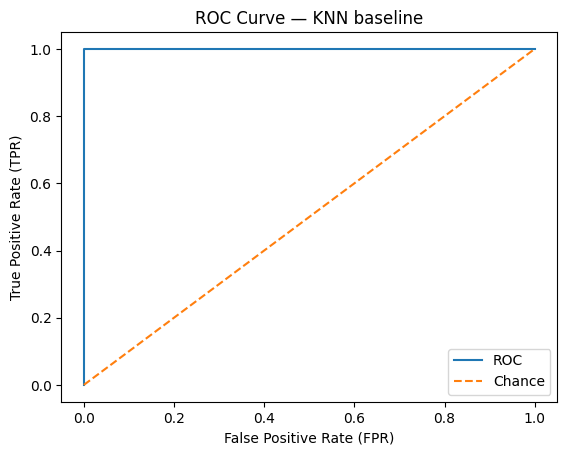

In [7]:
plt.figure()
plt.plot(fpr, tpr_pts, label="ROC")
plt.plot([0, 1], [0, 1], linestyle="--", label="Chance")
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curve — KNN baseline")
plt.legend()
plt.show()

In [ ]:
#-------------------------------EX3---------------------------------------

import numpy as np
from pyod.utils.data import generate_data

X_train, X_test, y_train, y_test = generate_data(
    n_train=400,
    n_test=100,
    n_features=1,     # 1D 
    contamination=0.1,
    random_state=1
)

y_train = y_train.astype(int)
y_test = y_test.astype(int)

X_train.shape, X_test.shape, np.bincount(y_train), np.bincount(y_test)


((400, 1), (100, 1), array([360,  40]), array([90, 10]))

In [9]:
mu = X_train.mean()
sigma = X_train.std()

# Z-score 
z = np.abs((X_test - mu) / sigma)

threshold = np.quantile(np.abs((X_train - mu) / sigma), 1 - 0.1)  # 0.1 = contamination
print(f"Mean={mu:.3f}, Std={sigma:.3f}, Threshold={threshold:.3f}")

Mean=4.590, Std=1.729, Threshold=1.224


In [11]:
y_pred_test = (z > threshold).astype(int).ravel()

from sklearn.metrics import confusion_matrix

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test).ravel()
tpr = tp / (tp + fn) if (tp + fn) else 0.0
tnr = tn / (tn + fp) if (tn + fp) else 0.0
balanced_acc = 0.5 * (tpr + tnr)

print(f"TN={tn} FP={fp} FN={fn} TP={tp}")
print(f"Balanced Accuracy = {balanced_acc:.3f}")


TN=86 FP=4 FN=1 TP=9
Balanced Accuracy = 0.928


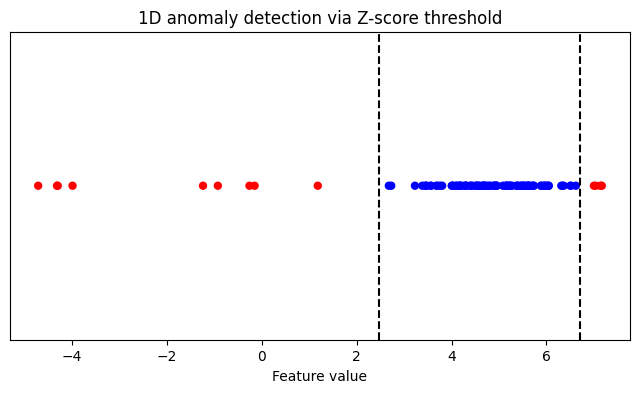

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.scatter(X_test, np.zeros_like(X_test), c=["red" if y==1 else "blue" for y in y_pred_test], s=25)
plt.axvline(mu - threshold*sigma, color="black", linestyle="--")
plt.axvline(mu + threshold*sigma, color="black", linestyle="--")
plt.title("1D anomaly detection via Z-score threshold")
plt.xlabel("Feature value")
plt.yticks([])
plt.show()


In [ ]:
#--------------------------------EX4-------------------------------------

import numpy as np
from pyod.utils.data import generate_data

# 2D 
X_train, X_test, y_train, y_test = generate_data(
    n_train=400,
    n_test=100,
    n_features=2,
    contamination=0.1,
    random_state=7
)

y_train = y_train.astype(int)
y_test = y_test.astype(int)
X_train.shape, X_test.shape, np.bincount(y_train), np.bincount(y_test)

((400, 2), (100, 2), array([360,  40]), array([90, 10]))

In [14]:
import numpy as np

mu = X_train.mean(axis=0)
Sigma = np.cov(X_train, rowvar=False)

eps = 1e-6
Sigma_reg = Sigma + eps * np.eye(Sigma.shape[0])

Sigma_inv = np.linalg.inv(Sigma_reg)

def mahalanobis(X, mu, Sigma_inv):
    D = X - mu
    return np.einsum('ij,jk,ik->i', D, Sigma_inv, D)

d2_train = mahalanobis(X_train, mu, Sigma_inv) 
d2_test  = mahalanobis(X_test,  mu, Sigma_inv)

d2_train[:5], d2_test[:5]

(array([1.68568595, 0.25890052, 0.25412686, 0.82773677, 0.611364  ]),
 array([0.19399164, 0.93274386, 0.25653865, 0.26394572, 0.43409599]))

In [15]:
from sklearn.metrics import confusion_matrix

cont = 0.1  

thr_quantile = np.quantile(d2_train, 1 - cont)

from scipy.stats import chi2
k = X_train.shape[1]
thr_chi2 = chi2.ppf(1 - cont, df=k)

thr_quantile, thr_chi2

(np.float64(3.3651275905297857), np.float64(4.605170185988092))

In [16]:
def eval_threshold(d2_test, thr):
    y_pred = (d2_test > thr).astype(int)  
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    tpr = tp / (tp + fn) if (tp + fn) else 0.0
    tnr = tn / (tn + fp) if (tn + fp) else 0.0
    ba = 0.5 * (tpr + tnr)
    return ba, (tn, fp, fn, tp)

ba_q, cm_q = eval_threshold(d2_test, thr_quantile)
ba_c, cm_c = eval_threshold(d2_test, thr_chi2)

print(f"[Quantile]   BA={ba_q:.3f},  CM={cm_q},  thr={thr_quantile:.3f}")
print(f"[Chi-square] BA={ba_c:.3f},  CM={cm_c},  thr={thr_chi2:.3f}")

[Quantile]   BA=0.739,  CM=(np.int64(88), np.int64(2), np.int64(5), np.int64(5)),  thr=3.365
[Chi-square] BA=0.744,  CM=(np.int64(89), np.int64(1), np.int64(5), np.int64(5)),  thr=4.605


In [17]:
import numpy as np
import matplotlib.pyplot as plt

def hat_matrix(X):
    XtX = X.T @ X
    reg = 1e-8 * np.eye(XtX.shape[0])
    H = X @ np.linalg.pinv(XtX + reg) @ X.T
    return H

def leverage_scores(X):
    return np.diag(hat_matrix(X))

def topk_idx(arr, k=5):
    k = min(k, len(arr))
    return np.argpartition(arr, -k)[-k:]